In [1]:
import numpy as np
import pandas as pd
import random
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, fbeta_score, log_loss, confusion_matrix 
from sklearn.impute import KNNImputer
from imblearn.under_sampling import NearMiss 
from imblearn.over_sampling import BorderlineSMOTE
import sys
import math
import shap

sys.path.insert(0, "../../../../Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *

import warnings
warnings.filterwarnings("ignore")

In [2]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'

Q = 'Q2'
q = Q.lower()

In [3]:
path = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_Q1_2011_2022.csv'

dataset = read_data(path)
dataset.head()

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,culex_pipiens,WNV_cases
0,2011,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,3.154111,6.229173,9.327499,7.851225,14.583333,18.666667,49.122807,768.952455,34.0,-4.0,38.0,9.166667,23.833333,23.833333,4.833333,1580.0,347.0,21.0,69.297060,585.0,195.0,195.0,488.0,0.253413,0.164233,0.382909,-0.382909,0.243740,0.189907,0.401026,-0.401026,0.044376,0.051454,0.050562,0.050562,70507.0,11806.0,44835.0,13866.0,72328.0,11360.0,44584.0,16384.0,2016.25,5025.2,5265.4,10083.753176,2604.220647,14.0,151.983874,145.068848,169.450815,0.0,3.764491,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,0.0,18028.909091,1
1,2011,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139532,40.695359,3.805192,6.833876,9.632381,7.258680,16.125000,20.083333,46.705426,865.533204,39.0,-4.0,43.0,10.333333,26.166667,26.500000,5.333333,1341.0,362.0,8.0,88.115950,512.0,157.0,210.0,391.0,0.331371,-0.125325,0.181410,-0.181410,0.328781,-0.127656,0.175605,-0.175605,0.053834,0.060592,0.055271,0.055271,544496.0,87330.0,375115.0,82051.0,593794.0,84172.0,402246.0,107376.0,19627.51,9804.6,10058.8,4609.324076,1275.656385,3.0,156.077628,106.345725,180.535489,0.0,3.928386,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,0.0,16320.850394,1
2,2011,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,3.615530,7.183375,10.120540,4.959644,16.083333,21.500000,46.739130,890.054476,41.0,-5.0,46.0,9.833333,26.166667,27.000000,5.000000,1417.0,379.0,10.0,78.775725,584.0,198.0,223.0,377.0,0.238927,-0.089832,0.144111,-0.144111,0.241070,-0.091286,0.144951,-0.144951,0.023444,0.040297,0.033327,0.033327,40335.0,5963.0,24603.0,9769.0,41005.0,5680.0,23436.0,11889.0,1124.52,5809.2,5920.4,14539.491549,1973.650189,5.0,180.265199,154.698694,180.171598,0.0,10.143914,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,2.0,0.0,14407.043956,0
3,2011,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,3.344699,6.643856,9.787595,6.495086,14.750000,19.166667,47.916667,790.425662,36.0,-4.0,40.0,9.333333,24.500000,24.500000,4.666667,1630.0,348.0,19.0,63.316479,629.0,219.0,219.0,490.0,0.257757,0.126741,0.363656,-0.363656,0.254301,0.126465,0.361181,-0.361181,0.039384,0.052719,0.050437,0.050437,70390.0,11159.0,44537.0,14694.0,71954.0,11052.0,43212.0,17690.0,1938.34,5025.2,5265.4,20467.087760,2556.132830,4.0,227.370939,344.084297,191.478748,0.0,1.165700,31.0,30.0,30.0,10.0,10.0,1.0,6.0,6.0,2.0,0.0,15360.034091,1
4,2011,EL52,κεντρικη μακεδονια,EL525,πιερια,22.441443,40.269748,4.506731,6.992178,8.838208,9.737422,15.916667,18.333333,45.833333,769.247960,37.0,-3.0,40.0,15.666667,25.500000,25.500000,6.500000,1470.0,325.0,27.0,70.741701,556.0,174.0,174.0,437.0,0.269825,0.101198,0.347946,-0.347946,0.258944,0.119827,0.353585,-0.353585,0.044928,0.065635,0.063431,0.063431,62665.0,10433.0,40170.0,12062.0,65045.0,10152.0,40273.0,14620.0,1725.03,5025.2,5265.4,18189.327795,588.383582,13.0,62.313885,249.228982,171.825615,0.0,1.045132,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,0.0,18910.088889,0


In [4]:
dataset.shape

(652, 73)

In [5]:
## Simple output binarization

# dataset.drop_duplicates(keep='first', inplace=True, ignore_index=True)
# dataset

In [6]:
dataset.columns

Index(['year', 'NUTS2_ID', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'x', 'y',
       'min_temp_q1', 'mean_temp_q1', 'max_temp_q1', 'prec_q1', 'bio1', 'bio2',
       'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10',
       'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18',
       'bio19', 'ndvi_q1', 'ndwi_q1', 'ndmi_q1', 'ndbi_q1', 'ndvi_mean_q1',
       'ndwi_mean_q1', 'ndmi_mean_q1', 'ndbi_mean_q1', 'ndvi_std_q1',
       'ndwi_std_q1', 'ndmi_std_q1', 'ndbi_std_q1', 'M_TOTAL', 'M_Y_LT_15',
       'M_Y15-64', 'M_Y_GE65', 'F_TOTAL', 'F_Y_LT_15', 'F_Y15-64', 'F_Y_GE65',
       'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL', 'distance_to_coast',
       'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
       'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km',
       'flow_accu_200m', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type1',
       'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5', 'lw', 'qc',
       'culex_pipiens', 'WNV_cases'],
      dtype='objec

In [7]:
print(f'Number of NUTS3 Units in dataset: {len(dataset.NUTS3_NAME.unique())}')

Number of NUTS3 Units in dataset: 7


In [8]:
dsc = dataframe_describe(dataset, target_column = 'WNV_cases')
dsc.head(15)

,year,non-case,case,total,percentage
0,2011,2,31,33,5.06%
1,2012,3,20,23,3.53%
2,2013,3,21,24,3.68%
3,2014,7,0,7,1.07%
4,2015,7,0,7,1.07%
5,2016,7,0,7,1.07%
6,2017,7,0,7,1.07%
7,2018,0,117,117,17.94%
8,2019,0,53,53,8.13%
9,2020,0,93,93,14.26%


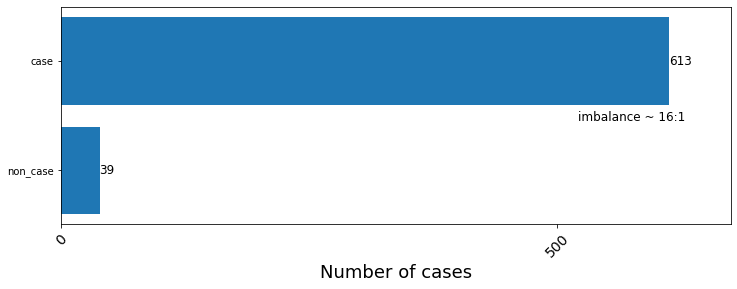

In [9]:
plot_imbalance(dataset, target_column='WNV_cases')

In [10]:
majority_class = 1
near_u = 0
smote = 2
scaler = 'minmax'
weight_multiplier = 1

years_to_remove = []

features_to_remove = ['x', 'y', 'year', 'distance_to_coast',
       'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
       'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km',
       'flow_accu_200m', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type1',
       'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5', 'lw', 'qc',]

# geo_vars
# features_to_remove = ['x', 'y', 'year', 'lc_type1', 'lc_type3', 'lc_type4', 'lc_type5','lw', 'qc',]

#features_to_remove=[]
#years_to_remove = []

In [11]:
model_coefficients = []
model_shaps = []
results_train = pd.DataFrame()
results_test = pd.DataFrame()
feature_names = dataset.select_dtypes(exclude=['object']).drop(columns = ['WNV_cases'] 
                                                               + features_to_remove).columns

print(feature_names)

Index(['min_temp_q1', 'mean_temp_q1', 'max_temp_q1', 'prec_q1', 'bio1', 'bio2',
       'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10',
       'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18',
       'bio19', 'ndvi_q1', 'ndwi_q1', 'ndmi_q1', 'ndbi_q1', 'ndvi_mean_q1',
       'ndwi_mean_q1', 'ndmi_mean_q1', 'ndbi_mean_q1', 'ndvi_std_q1',
       'ndwi_std_q1', 'ndmi_std_q1', 'ndbi_std_q1', 'M_TOTAL', 'M_Y_LT_15',
       'M_Y15-64', 'M_Y_GE65', 'F_TOTAL', 'F_Y_LT_15', 'F_Y15-64', 'F_Y_GE65',
       'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL', 'culex_pipiens'],
      dtype='object')


In [12]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
x = dataset.drop(columns = ['WNV_cases'])
y = dataset['WNV_cases']
fold = 0
  
for train_idx, test_idx in skf.split(x, y):
    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]
    data_test = data_test.drop_duplicates(keep='first')
    if len(years_to_remove) > 0:
        data_train = data_train.loc[~data_train['year'].isin(years_to_remove)]
    
    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)
    
    X_train, X_test, y_train, y_test, scaler, imputer = train_test_split_transform(data_train, data_test, near_u, smote, 'WNV_cases', scaler, majority_class, features_to_remove)

    w0,w1 = calculate_weights_new(y_train, weight_multiplier)

    model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)

    trained_model, model_shap = train_lin_model(model, X_train, y_train, explain=True)

    train, test, coef = predict_lin_model_new(trained_model, X_train, y_train, X_test, y_test, data_test, day_col = None, month_col = None, spatial_col = 'NUTS3_NAME')

    results_train = results_train.append(train, ignore_index = True)
    results_test = results_test.append(test, ignore_index = True)
    model_coefficients.append(coef)
    model_shaps.append(model_shap)
    
    print(f"Fold: {fold} || w0:{w0}, w1:{w1} || ##")
    fold = fold + 1

shap_values= np.concatenate(model_shaps, axis=0)

Fold: 0 || w0:6, w1:1 || ##
Fold: 1 || w0:6, w1:1 || ##
Fold: 2 || w0:6, w1:1 || ##
Fold: 3 || w0:6, w1:1 || ##
Fold: 4 || w0:6, w1:1 || ##
Fold: 5 || w0:6, w1:1 || ##
Fold: 6 || w0:6, w1:1 || ##
Fold: 7 || w0:6, w1:1 || ##
Fold: 8 || w0:6, w1:1 || ##
Fold: 9 || w0:6, w1:1 || ##


In [13]:
feature_names

Index(['min_temp_q1', 'mean_temp_q1', 'max_temp_q1', 'prec_q1', 'bio1', 'bio2',
       'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10',
       'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18',
       'bio19', 'ndvi_q1', 'ndwi_q1', 'ndmi_q1', 'ndbi_q1', 'ndvi_mean_q1',
       'ndwi_mean_q1', 'ndmi_mean_q1', 'ndbi_mean_q1', 'ndvi_std_q1',
       'ndwi_std_q1', 'ndmi_std_q1', 'ndbi_std_q1', 'M_TOTAL', 'M_Y_LT_15',
       'M_Y15-64', 'M_Y_GE65', 'F_TOTAL', 'F_Y_LT_15', 'F_Y15-64', 'F_Y_GE65',
       'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL', 'culex_pipiens'],
      dtype='object')

In [14]:
len(feature_names)

47

In [15]:
bioclimatic = ['bio1','bio2','bio3','bio4','bio5','bio6','bio7','bio8','bio9','bio10','bio11','bio12','bio13','bio14','bio15','bio16','bio17','bio18','bio19']
climate = [f'min_temp_{q}', f'mean_temp_{q}', f'max_temp_{q}', f'prec_{q}']
enviromental = [f'ndvi_{q}',f'ndwi_{q}',f'ndmi_{q}',f'ndbi_{q}',f'ndvi_mean_{q}',f'ndwi_mean_{q}',f'ndmi_mean_{q}',f'ndbi_mean_{q}',f'ndvi_std_{q}',f'ndwi_std_{q}',f'ndmi_std_{q}',f'ndbi_std_{q}']
demographic = ['M_TOTAL','M_Y_LT_15','M_Y15-64','M_Y_GE65','F_TOTAL','F_Y_LT_15','F_Y15-64','F_Y_GE65']
vectors = ['culex_pipiens']
trade = ['L_TOTAL',	'UNL_TOTAL']
economic = ['MIO_EUR']

In [16]:
len(bioclimatic+climate+enviromental+demographic+vectors+trade+economic)

47

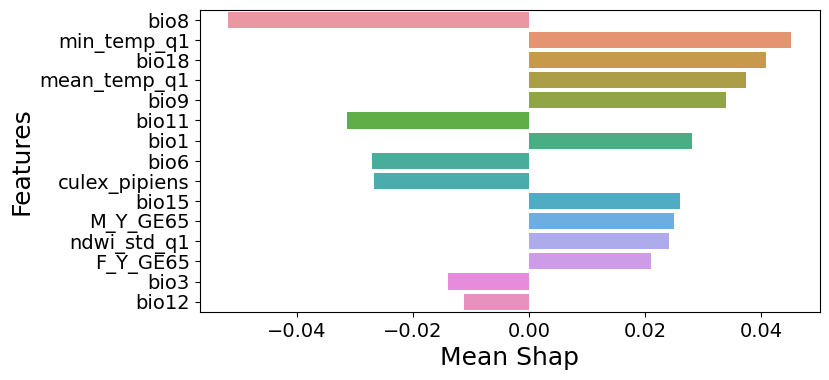

In [17]:
mean_shap = shap_values.mean(axis=0)
shp = mean_shap.shape[0]
mean_shap = mean_shap.reshape(1,shp)

shaps = plot_feature_importance(mean_shap, feature_names, x_label = 'Mean Shap', top = 15, figure_size = (8, 4))

shaps['weights_abs'] = shaps['weights'].apply(lambda x: abs(x))

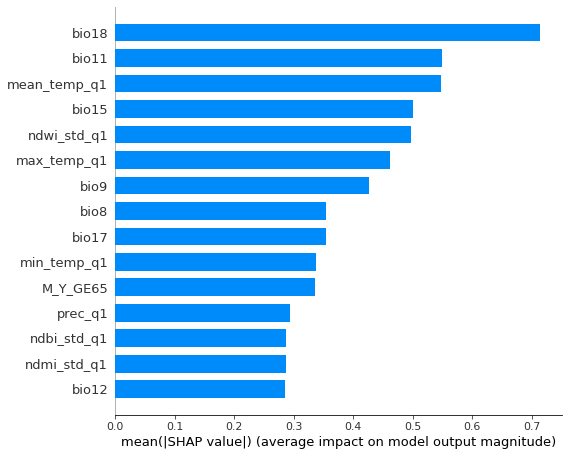

In [18]:
shap.summary_plot(shap_values, features = X_train, feature_names = feature_names, plot_type='bar', max_display=15)

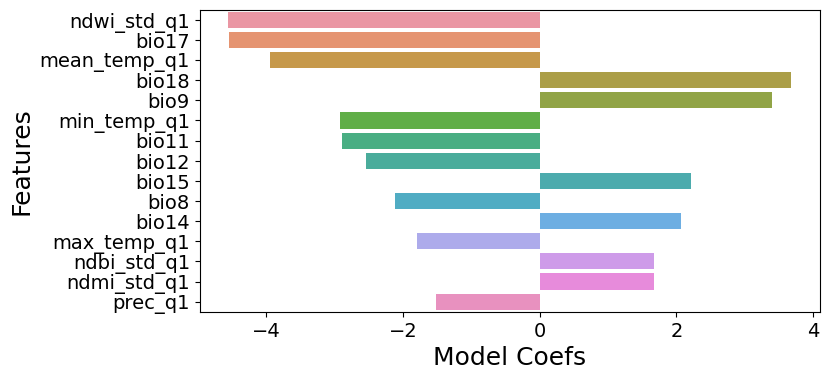

In [19]:
coefs = plot_feature_importance(model_coefficients, feature_names, x_label = 'Model Coefs', top = 15, figure_size = (8, 4))

,features,weights
0,bioclimatic,0.292946
3,demographic,0.066452
4,vectors,0.026677
5,trade,0.010587
6,economic,0.003859
1,climate,0.000000
2,enviromental,0.000000


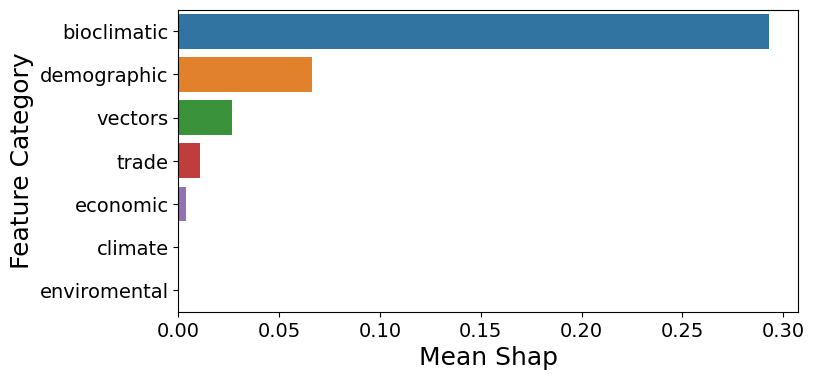

In [20]:
df_bioclimatic = shaps.loc[shaps['features'].isin(bioclimatic)].drop(columns=['weights'])
df_climate = shaps.loc[shaps['features'].isin(climate)].drop(columns=['weights'])
df_enviromental = shaps.loc[shaps['features'].isin(enviromental)].drop(columns=['weights'])
df_demographic = shaps.loc[shaps['features'].isin(demographic)].drop(columns=['weights'])
df_vectors = shaps.loc[shaps['features'].isin(vectors)].drop(columns=['weights'])
df_trade = shaps.loc[shaps['features'].isin(trade)].drop(columns=['weights'])
df_economic = shaps.loc[shaps['features'].isin(economic)].drop(columns=['weights'])

categories = {'Category': ['bioclimatic', 'climate', 'enviromental', 'demographic', 'vectors', 'trade', 'economic'], 
              'Mean_Shap': [df_bioclimatic.weights_abs.sum(),df_climate.weights_abs.sum(),df_enviromental.weights_abs.sum(),
                            df_demographic.weights_abs.sum(),df_vectors.weights_abs.sum(),df_trade.weights_abs.sum(),df_economic.weights_abs.sum()]}

categories_df = pd.DataFrame.from_dict(categories)

categories_df.sort_values(by = 'Mean_Shap', ascending=False)

mean_shap_categories = categories_df['Mean_Shap']
mean_shap_categories = mean_shap_categories.to_numpy().reshape(1,7)

plot_feature_importance(mean_shap_categories, categories_df['Category'], y_label='Feature Category', x_label = 'Mean Shap', figure_size = (8, 4))

,features,weights
4,vectors,0.026677
0,bioclimatic,0.015418
3,demographic,0.008306
5,trade,0.005294
6,economic,0.003859
1,climate,NaN
2,enviromental,NaN


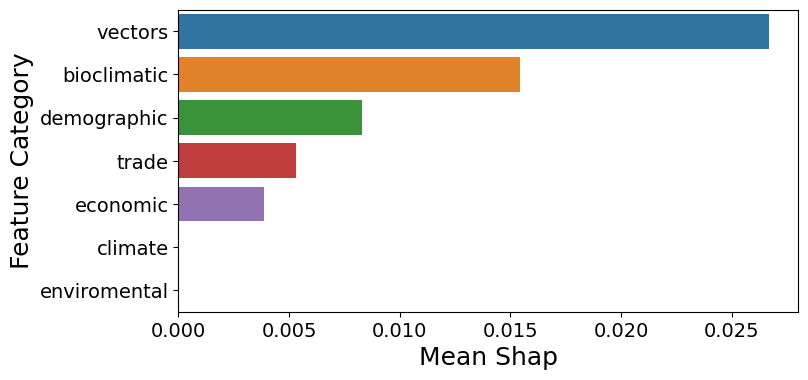

In [21]:
df_bioclimatic = shaps.loc[shaps['features'].isin(bioclimatic)].drop(columns=['weights'])
df_climate = shaps.loc[shaps['features'].isin(climate)].drop(columns=['weights'])
df_enviromental = shaps.loc[shaps['features'].isin(enviromental)].drop(columns=['weights'])
df_demographic = shaps.loc[shaps['features'].isin(demographic)].drop(columns=['weights'])
df_vectors = shaps.loc[shaps['features'].isin(vectors)].drop(columns=['weights'])
df_trade = shaps.loc[shaps['features'].isin(trade)].drop(columns=['weights'])
df_economic = shaps.loc[shaps['features'].isin(economic)].drop(columns=['weights'])

categories = {'Category': ['bioclimatic', 'climate', 'enviromental', 'demographic', 'vectors', 'trade', 'economic'], 
              'Mean_Shap': [df_bioclimatic.weights_abs.mean(),df_climate.weights_abs.mean(),df_enviromental.weights_abs.mean(),
                            df_demographic.weights_abs.mean(),df_vectors.weights_abs.mean(),df_trade.weights_abs.mean(),df_economic.weights_abs.mean()]}

categories_df = pd.DataFrame.from_dict(categories)

categories_df.sort_values(by = 'Mean_Shap', ascending=False)

mean_shap_categories = categories_df['Mean_Shap']
mean_shap_categories = mean_shap_categories.to_numpy().reshape(1,7)

plot_feature_importance(mean_shap_categories, categories_df['Category'], y_label='Feature Category', x_label = 'Mean Shap', figure_size = (8, 4))

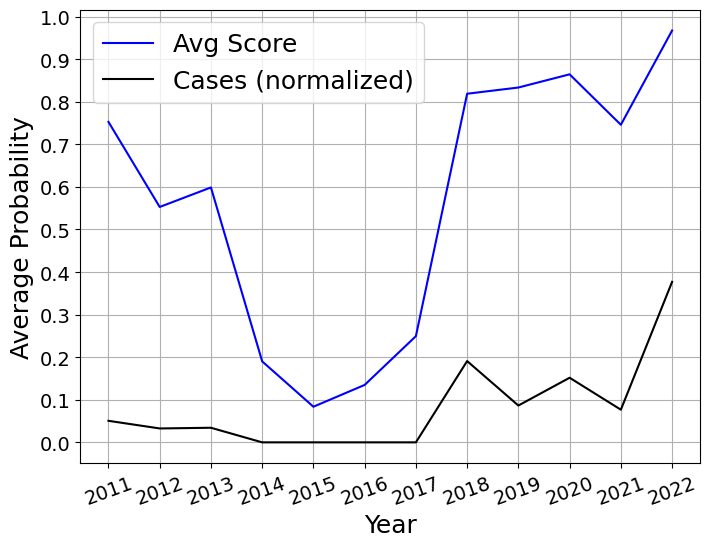

In [22]:
plot_trend_curve(results_test, score_col='score', cases=list(dsc['case']))

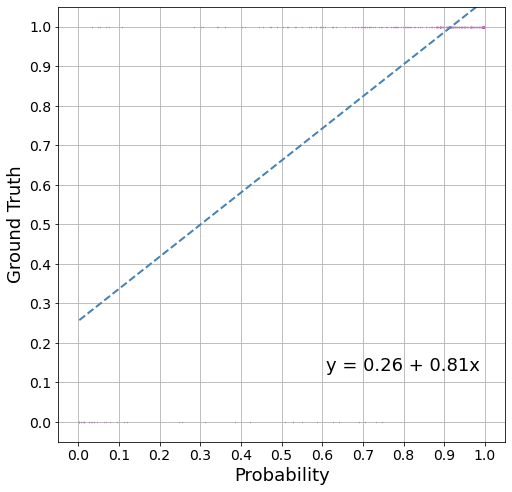

(0.25552898103148586, 0.811523369640448)

In [23]:
plot_probability_curve(results_test)

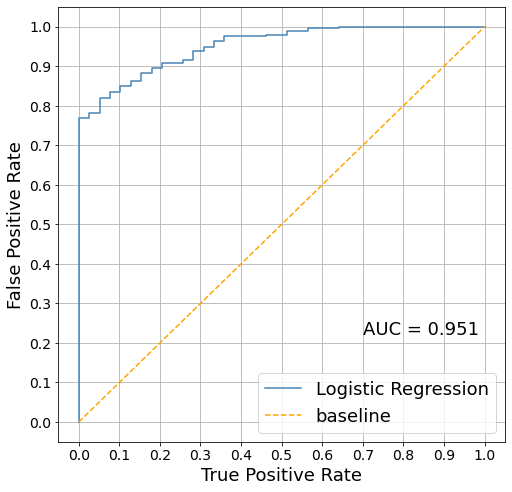

(0.0513, 0.8185, 0.7052, 0.8812)

In [24]:
plot_roc_curve(results_test)

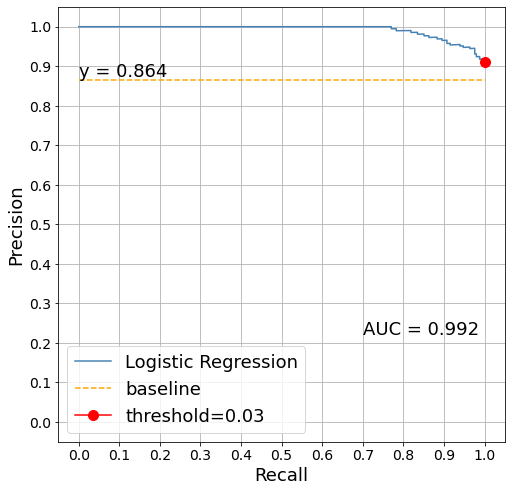

(1.0, 0.91, 0.03, 0.9802)

In [25]:
plot_pr_curve(results_test, plot_fbeta=True)

In [26]:
results_test

,NUTS3_NAME,year,case,score
0,ημαθια,2022,1,0.999253
1,ημαθια,2022,1,0.999103
2,ημαθια,2022,1,0.999023
3,ημαθια,2022,1,0.998973
4,ημαθια,2022,1,0.998918
...,...,...,...,...
282,πιερια,2015,0,0.005967
283,πελλα,2015,0,0.002251
284,κιλκις,2015,0,0.001601
285,ημαθια,2015,0,0.001387


In [27]:
results_test['pred_01'] = results_test['score'].apply(lambda x: 1 if x>= 0.1 else 0)
results_test['pred_02'] = results_test['score'].apply(lambda x: 1 if x>= 0.2 else 0)
results_test['pred_05'] = results_test['score'].apply(lambda x: 1 if x>= 0.5 else 0)

In [28]:
results_test

,NUTS3_NAME,year,case,score,pred_01,pred_02,pred_05
0,ημαθια,2022,1,0.999253,1,1,1
1,ημαθια,2022,1,0.999103,1,1,1
2,ημαθια,2022,1,0.999023,1,1,1
3,ημαθια,2022,1,0.998973,1,1,1
4,ημαθια,2022,1,0.998918,1,1,1
...,...,...,...,...,...,...,...
282,πιερια,2015,0,0.005967,0,0,0
283,πελλα,2015,0,0.002251,0,0,0
284,κιλκις,2015,0,0.001601,0,0,0
285,ημαθια,2015,0,0.001387,0,0,0


In [29]:
accuracy_01 = accuracy_score(results_test.case, results_test.pred_01)
balanced_accuracy_01 = balanced_accuracy_score(results_test.case, results_test.pred_01)
fb_score_01 = fbeta_score(results_test.case, results_test.pred_01, beta = 1, labels = [0,1], zero_division = 0)
precision_01 = precision_score(results_test.case, results_test.pred_01, labels = [0,1], zero_division = 0)
recall_01 = recall_score(results_test.case, results_test.pred_01, labels = [0,1], zero_division = 0)
logloss_01 = log_loss(results_test.case, results_test.score, labels = [0,1])

In [30]:
accuracy_02 = accuracy_score(results_test.case, results_test.pred_02)
balanced_accuracy_02 = balanced_accuracy_score(results_test.case, results_test.pred_02)
fb_score_02 = fbeta_score(results_test.case, results_test.pred_02, beta = 1, labels = [0,1], zero_division = 0)
precision_02 = precision_score(results_test.case, results_test.pred_02, labels = [0,1], zero_division = 0)
recall_02 = recall_score(results_test.case, results_test.pred_02, labels = [0,1], zero_division = 0)
logloss_02 = log_loss(results_test.case, results_test.score, labels = [0,1])

In [31]:
accuracy_05 = accuracy_score(results_test.case, results_test.pred_05)
balanced_accuracy_05 = balanced_accuracy_score(results_test.case, results_test.pred_05)
fb_score_05 = fbeta_score(results_test.case, results_test.pred_05, beta = 1, labels = [0,1], zero_division = 0)
precision_05 = precision_score(results_test.case, results_test.pred_05, labels = [0,1], zero_division = 0)
recall_05 = recall_score(results_test.case, results_test.pred_05, labels = [0,1], zero_division = 0)
logloss_05 = log_loss(results_test.case, results_test.score, labels = [0,1])

In [32]:
thr_01 = {'accuracy': accuracy_01, 'balanced_accuracy': balanced_accuracy_01, 
          'f1_score': fb_score_01, 'precision': precision_01, 'recall': recall_01, 'logloss': logloss_01}

thr_02 = {'accuracy': accuracy_02, 'balanced_accuracy': balanced_accuracy_02, 
          'f1_score': fb_score_02, 'precision': precision_02, 'recall': recall_02, 'logloss': logloss_02}

thr_05 = {'accuracy': accuracy_05, 'balanced_accuracy': balanced_accuracy_05, 
          'f1_score': fb_score_05, 'precision': precision_05, 'recall': recall_05, 'logloss': logloss_05}

In [33]:
results_df = pd.DataFrame([thr_01, thr_02, thr_05])
results_df.index = ['Threshold: 0.1', 'Threshold: 0.2', 'Threshold: 0.5']

In [34]:
results_df

,accuracy,balanced_accuracy,f1_score,precision,recall,logloss
Threshold: 0.1,0.919861,0.759150,0.954813,0.931034,0.979839,0.266101
Threshold: 0.2,0.923345,0.782775,0.956522,0.937984,0.975806,0.266101
Threshold: 0.5,0.891986,0.818652,0.936345,0.953975,0.919355,0.266101
